**Libraries Setup**

In [ ]:
# Install official PhysioNet database downloader (wfdb) and core machine learning frameworks
!pip install wfdb scipy matplotlib numpy pandas seaborn scikit-learn torch imbalanced-learn

import os
import random
from collections import defaultdict, deque
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt

import torch
import torch.nn as nn
import torch.nn.functional as F
import wfdb
from imblearn.over_sampling import SMOTE

# Establish rigid random seed initialization for absolute sequence reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Automatically hook into CUDA GPU acceleration if available in Colab
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Streaming Engine Execution Platform: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 87.6 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
Streaming Engine Execution Platform: cuda


In [ ]:
from google.colab import drive
import os

# Ensure the mount point is clean before attempting to mount
MOUNT_POINT = '/content/drive'

# Explicitly remove any existing contents in the mount point
!rm -rf {MOUNT_POINT}/*

drive.mount(MOUNT_POINT, force_remount=True)

Mounted at /content/drive


In [ ]:
def pytorch_bandpass_filter(data_tensor, lowcut=0.5, highcut=40.0, fs=500.0, order=5):
    """
    Applies a Butterworth bandpass filter to a PyTorch tensor.
    Internally converts to NumPy, applies scipy.signal.filtfilt, and converts back.
    """
    if not isinstance(data_tensor, torch.Tensor):
        raise TypeError("Input data must be a PyTorch tensor.")
    data_np = data_tensor.cpu().numpy()
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    filtered_np = filtfilt(b, a, data_np)
    filtered_tensor = torch.from_numpy(filtered_np.copy()).float().to(data_tensor.device)
    return filtered_tensor

In [ ]:
DRIVE_ROOT_PATH = '/content/drive/MyDrive/'
ZIP_FILE_NAME = 'ecg-id-database-1.0.0.zip'
ZIP_FILE_PATH = os.path.join(DRIVE_ROOT_PATH, ZIP_FILE_NAME)
ACTUAL_DATA_PATH_IN_DRIVE = os.path.join(DRIVE_ROOT_PATH, 'ecg-id-database-1.0.0')
print(f"Zip file path: {ZIP_FILE_PATH}")
print(f"Actual data path in Drive (unzipped): {ACTUAL_DATA_PATH_IN_DRIVE}")

Zip file path: /content/drive/MyDrive/ecg-id-database-1.0.0.zip
Actual data path in Drive (unzipped): /content/drive/MyDrive/ecg-id-database-1.0.0


In [ ]:
import zipfile
import os

print("--- PHASE 1: DATA ACQUISITION FROM GOOGLE DRIVE ---")
source_path_for_records = None
def contains_hea_files(path):
    if not os.path.isdir(path):
        return False
    for root, _, files in os.walk(path):
        for file in files:
            if file.endswith('.hea'):
                return True
    return False
if contains_hea_files(ACTUAL_DATA_PATH_IN_DRIVE):
    print(f"Dataset found in expected unzipped location: {ACTUAL_DATA_PATH_IN_DRIVE}")
    source_path_for_records = ACTUAL_DATA_PATH_IN_DRIVE
else:
    if os.path.isfile(ZIP_FILE_PATH):
        print(f"Zip file found at '{ZIP_FILE_PATH}'. Unzipped dataset directory not found at {ACTUAL_DATA_PATH_IN_DRIVE}. Attempting to unzip...")
        os.makedirs(os.path.dirname(ACTUAL_DATA_PATH_IN_DRIVE), exist_ok=True)
        try:
            with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
                zip_ref.extractall(os.path.dirname(ACTUAL_DATA_PATH_IN_DRIVE))
            print("Unzipping complete.")
            if contains_hea_files(ACTUAL_DATA_PATH_IN_DRIVE):
                source_path_for_records = ACTUAL_DATA_PATH_IN_DRIVE
            else:
                print(f"Warning: Unzipping completed, but no .hea files found in {ACTUAL_DATA_PATH_IN_DRIVE}.")
                potential_nested_path = os.path.join(ACTUAL_DATA_PATH_IN_DRIVE, 'ecg-id-database-1.0.0')
                if contains_hea_files(potential_nested_path):
                    source_path_for_records = potential_nested_path
                    print(f"Found data in nested path after unzipping: {source_path_for_records}")
                else:
                    print("Could not locate data after unzipping, even in common nested paths.")

        except zipfile.BadZipFile:
            print(f"Error: '{ZIP_FILE_PATH}' is not a valid zip file. Please check the file.")
        except Exception as e:
            print(f"An error occurred during unzipping: {e}")
    elif os.path.isdir(ZIP_FILE_PATH):
        print(f"Detected '{ZIP_FILE_PATH}' as a directory (even though it ends with .zip).")
        print(f"Checking for records within '{ZIP_FILE_PATH}' or a common subfolder.")
        potential_subfolder = os.path.join(ZIP_FILE_PATH, 'ecg-id-database-1.0.0')
        if contains_hea_files(potential_subfolder):
            source_path_for_records = potential_subfolder
            print(f"Found data in subfolder: {source_path_for_records}")
        elif contains_hea_files(ZIP_FILE_PATH):
            source_path_for_records = ZIP_FILE_PATH
            print(f"Found data directly within: {source_path_for_records}")
        else:
            print(f"No .hea files found within '{ZIP_FILE_PATH}' or its expected subfolders.")
            print("Please ensure your dataset is located at the specified paths or correct the naming.")
    else:
        print(f"Error: Neither a file nor a directory found at {ZIP_FILE_PATH}.")
        print(f"Please ensure '{ZIP_FILE_PATH}' exists and is either a zip file or a directory containing the dataset.")

all_records = []
if source_path_for_records:
    print(f"Indexing records from: {source_path_for_records}")
    for root, dirs, files in os.walk(source_path_for_records):
        for file in files:
            if file.endswith('.hea'):
                record_base = os.path.splitext(file)[0]
                all_records.append(os.path.join(root, record_base))
    all_records = sorted(all_records)
    print(f"Data Acquisition Complete. Found {len(all_records)} valid clinical subject records.")
else:
    print("Data acquisition failed: No valid source path found.")

--- PHASE 1: DATA ACQUISITION FROM GOOGLE DRIVE ---
Dataset found in expected unzipped location: /content/drive/MyDrive/ecg-id-database-1.0.0
Indexing records from: /content/drive/MyDrive/ecg-id-database-1.0.0
Data Acquisition Complete. Found 620 valid clinical subject records.


In [ ]:
print("Re-parsing files and applying PyTorch-compatible Butterworth Bandpass Filter (0.5 Hz - 40.0 Hz)...")

raw_signals_list = [] # Will store NumPy arrays
filtered_signals_list = [] # Will store PyTorch tensors
subject_labels_list = []
records_info = []
unique_people = sorted(list(set([os.path.basename(os.path.dirname(r)) for r in all_records])))
person_to_idx = {name: idx for idx, name in enumerate(unique_people)}

for record_path in all_records:
    person_name = os.path.basename(os.path.dirname(record_path))
    class_label = person_to_idx[person_name]
    record = wfdb.rdrecord(record_path)
    raw_signal = record.p_signal[:, 0]
    raw_signal_tensor = torch.from_numpy(raw_signal).float().to(device)
    clean_signal_tensor = pytorch_bandpass_filter(raw_signal_tensor, fs=record.fs)
    raw_signals_list.append(raw_signal) # Store original NumPy array
    filtered_signals_list.append(clean_signal_tensor) # Store PyTorch tensor
    subject_labels_list.append(class_label)
    records_info.append({'fs': record.fs, 'units': record.units[0], 'person_name': person_name, 'record_name': os.path.basename(record_path)}) # Store info for plotting

print(f"Signal preprocessing complete for {len(filtered_signals_list)} records. Filtered signals are PyTorch tensors.")

Re-parsing files and applying PyTorch-compatible Butterworth Bandpass Filter (0.5 Hz - 40.0 Hz)...
Signal preprocessing complete for 620 records. Filtered signals are PyTorch tensors.


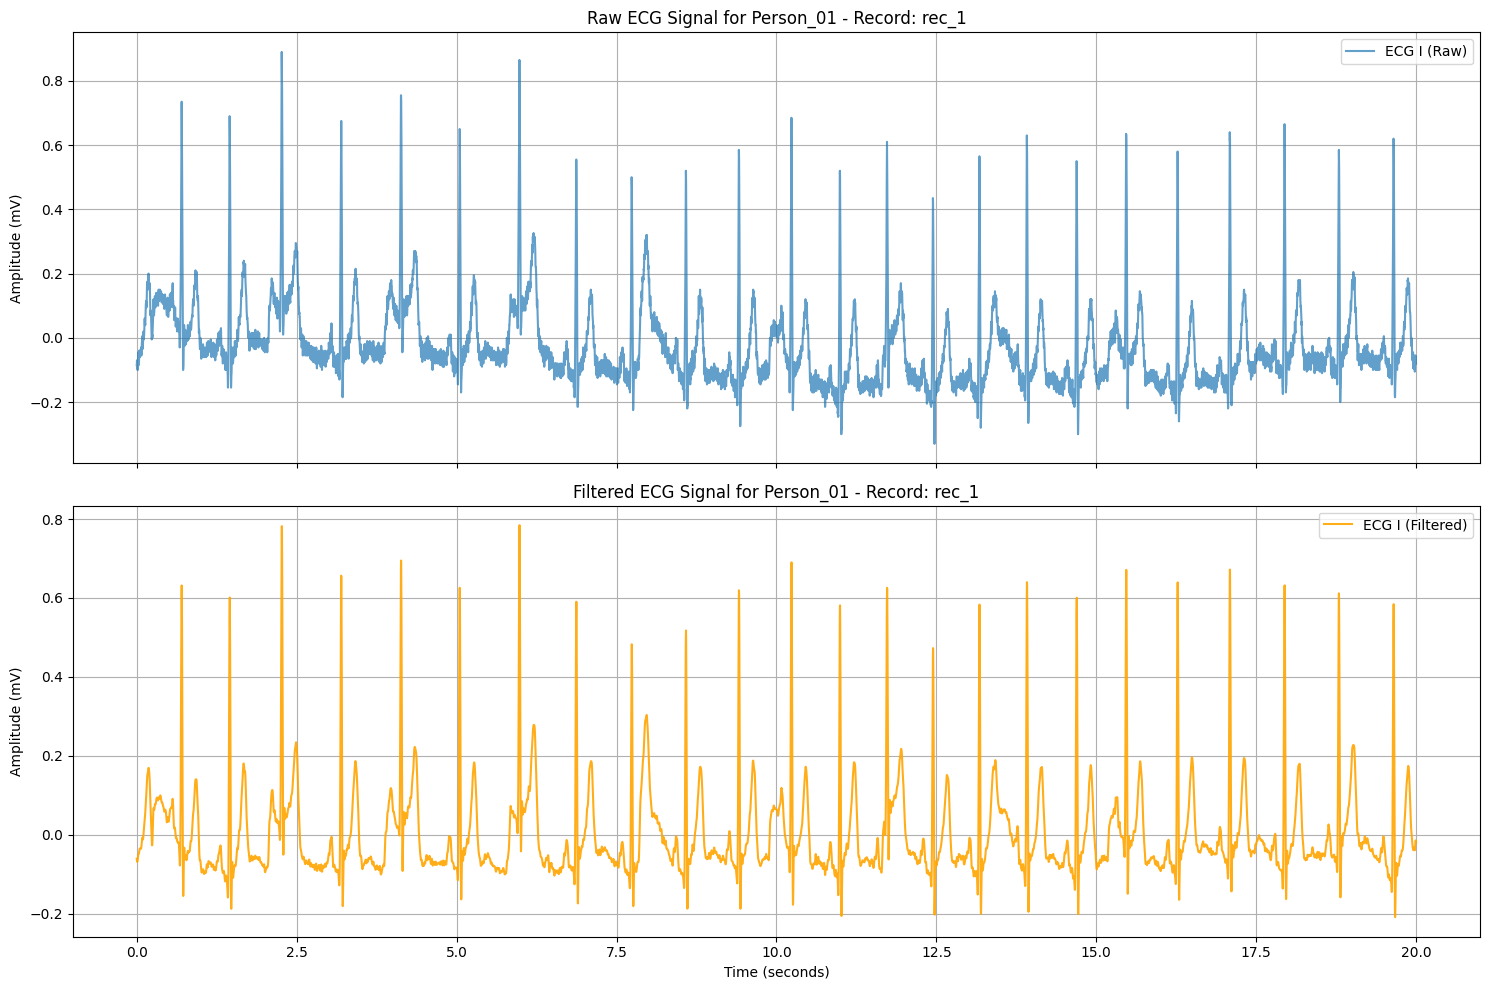

In [ ]:
# Select the first record for demonstration
demo_index = 0

sample_raw_signal = raw_signals_list[demo_index]
sample_filtered_signal_tensor = filtered_signals_list[demo_index]
sample_record_info = records_info[demo_index]

fs = sample_record_info['fs']
units = sample_record_info['units']
person_name = sample_record_info['person_name']
record_name = sample_record_info['record_name']

# Convert filtered signal tensor back to NumPy for plotting
sample_filtered_signal_np = sample_filtered_signal_tensor.cpu().numpy()

time_vector = np.arange(len(sample_raw_signal)) / fs

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

axes[0].plot(time_vector, sample_raw_signal, label='ECG I (Raw)', alpha=0.7)
axes[0].set_title(f'Raw ECG Signal for {person_name} - Record: {record_name}')
axes[0].set_ylabel(f'Amplitude ({units})')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(time_vector, sample_filtered_signal_np, label='ECG I (Filtered)', alpha=0.9, color='orange')
axes[1].set_title(f'Filtered ECG Signal for {person_name} - Record: {record_name}')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel(f'Amplitude ({units})')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import wfdb.processing

print("--- PHASE 3: QRS COMPLEX EXTRACTION AND DATA PREPARATION ---")
all_qrs_complexes = []
all_qrs_labels = []
QRS_WINDOW_SAMPLES = 200

print(f"Extracting QRS complexes with a window of {QRS_WINDOW_SAMPLES} samples around detected R-peaks...")

all_r_peaks_for_plotting = []

for i, filtered_signal_tensor in enumerate(filtered_signals_list):
    fs = records_info[i]['fs']
    class_label = subject_labels_list[i]
    person_name = records_info[i]['person_name']
    record_name = records_info[i]['record_name']

    try:
        filtered_signal_np = filtered_signal_tensor.cpu().numpy()
        r_peaks = wfdb.processing.xqrs_detect(sig=filtered_signal_np, fs=fs)
        all_r_peaks_for_plotting.append(r_peaks) # Store R-peaks for plotting
        for r_peak in r_peaks:
            start_idx = r_peak - (QRS_WINDOW_SAMPLES // 2)
            end_idx = r_peak + (QRS_WINDOW_SAMPLES // 2)

            if start_idx < 0:
                padding_before = -start_idx
                segment = filtered_signal_np[0:end_idx]
                qrs_complex_np = np.pad(segment, (padding_before, 0), 'constant', constant_values=0)
            elif end_idx > len(filtered_signal_np):
                padding_after = end_idx - len(filtered_signal_np)
                segment = filtered_signal_np[start_idx:len(filtered_signal_np)]
                qrs_complex_np = np.pad(segment, (0, padding_after), 'constant', constant_values=0)
            else:
                qrs_complex_np = filtered_signal_np[start_idx:end_idx]

            if len(qrs_complex_np) == QRS_WINDOW_SAMPLES:
                qrs_complex_tensor = torch.from_numpy(qrs_complex_np.copy()).float().to(device)
                all_qrs_complexes.append(qrs_complex_tensor)
                all_qrs_labels.append(class_label)
            else:
                print(f"Warning: QRS complex for {person_name}/{record_name} at R-peak {r_peak} has incorrect length {len(qrs_complex_np)}. Skipping.")

    except Exception as e:
        print(f"Error processing QRS for {person_name}/{record_name}: {e}")

print(f"Finished QRS extraction. Total QRS complexes extracted: {len(all_qrs_complexes)}")
print(f"Total QRS labels collected: {len(all_qrs_labels)}")

--- PHASE 3: QRS COMPLEX EXTRACTION AND DATA PREPARATION ---
Extracting QRS complexes with a window of 200 samples around detected R-peaks...
Learning initial signal parameters...
Failed to find 8 beats during learning.
Initializing using default parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Failed to find 8 beats during learning.
Initializing using default parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Failed to find 8 beats during learning.
Initializing using default parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Failed to find 8 beats during learning.
Initializing using default parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Failed to find 8 beats during learning.
Initializing using default parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameter

Generating and saving plots for R-peaks and QRS complexes to Google Drive...


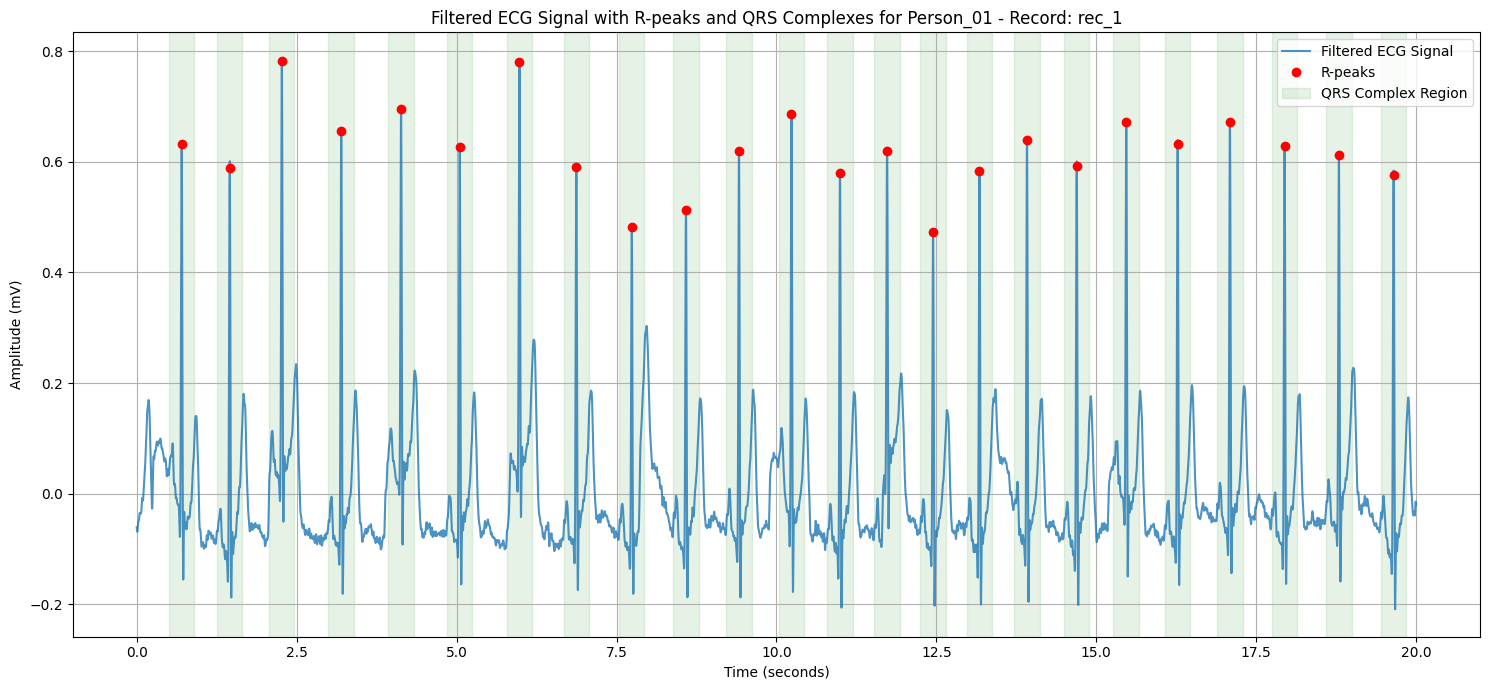

<Figure size 640x480 with 0 Axes>

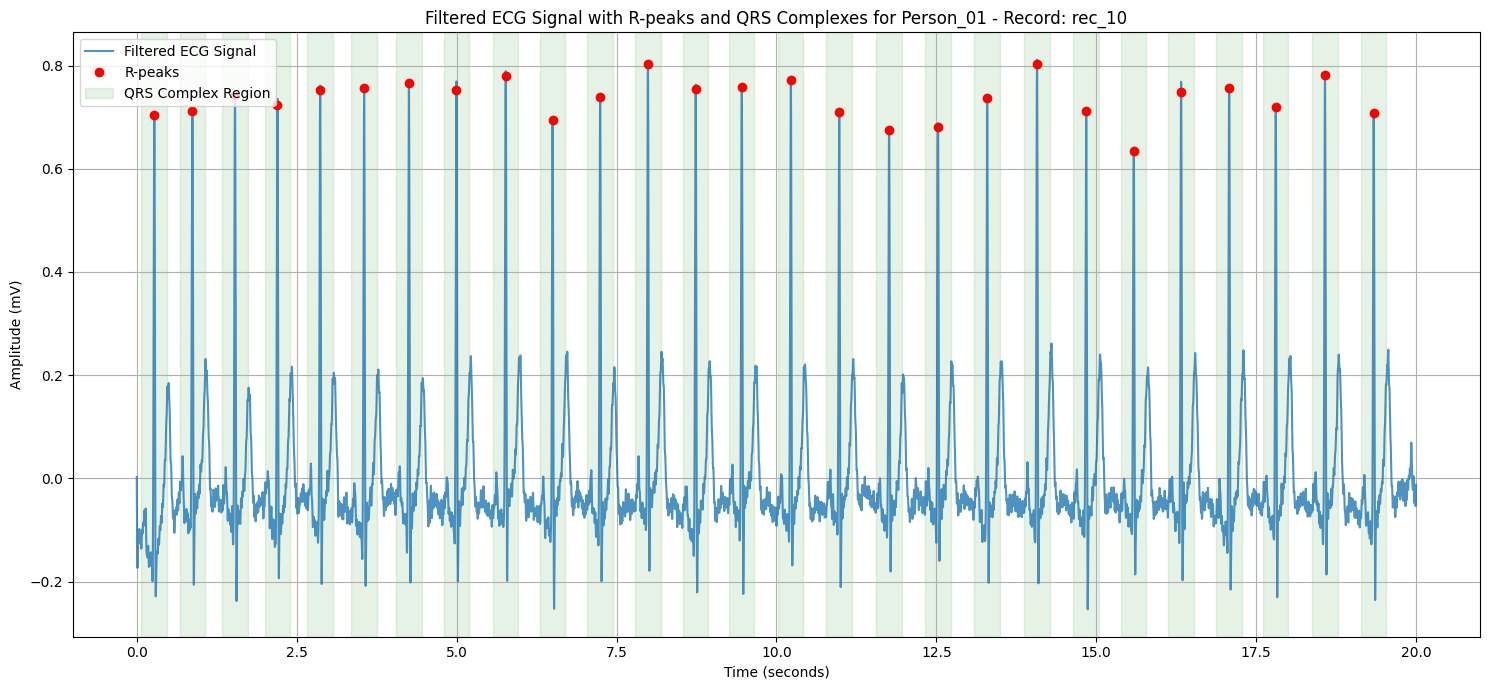

<Figure size 640x480 with 0 Axes>

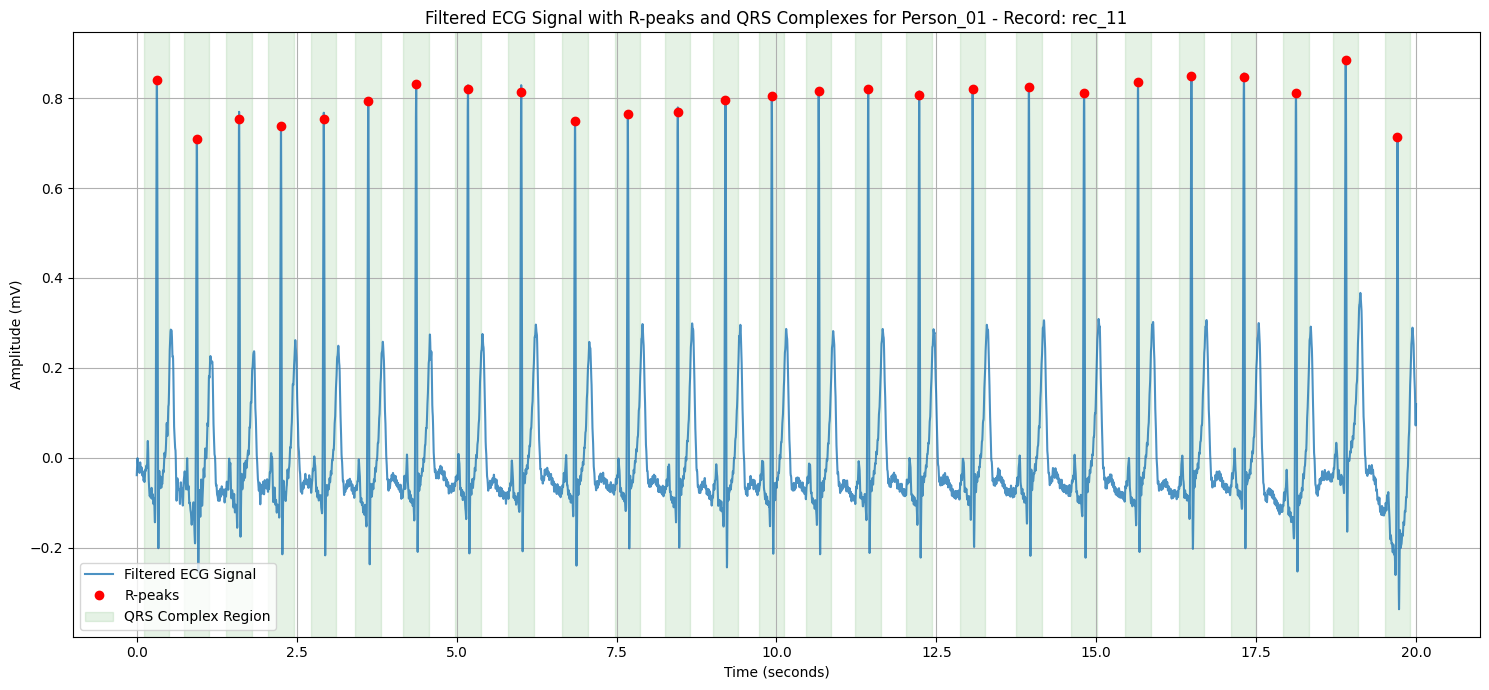

<Figure size 640x480 with 0 Axes>

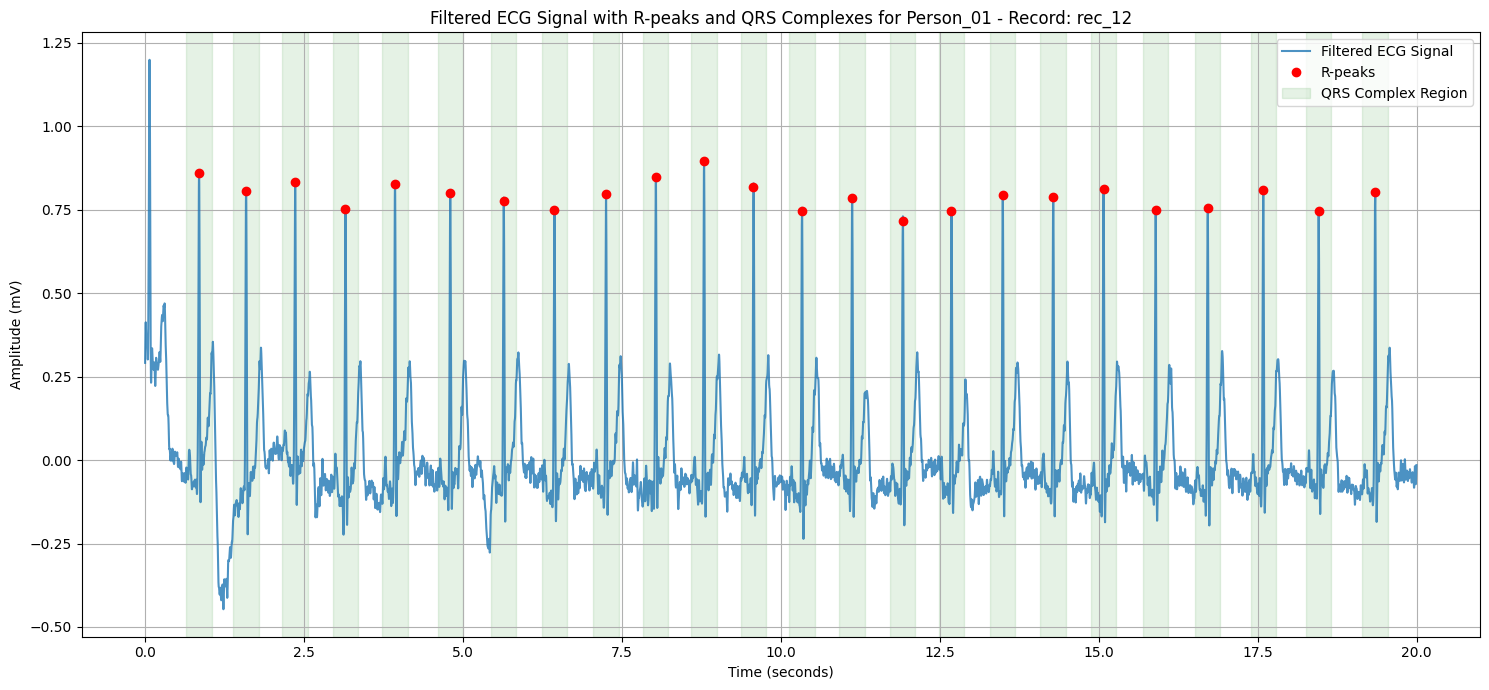

<Figure size 640x480 with 0 Axes>

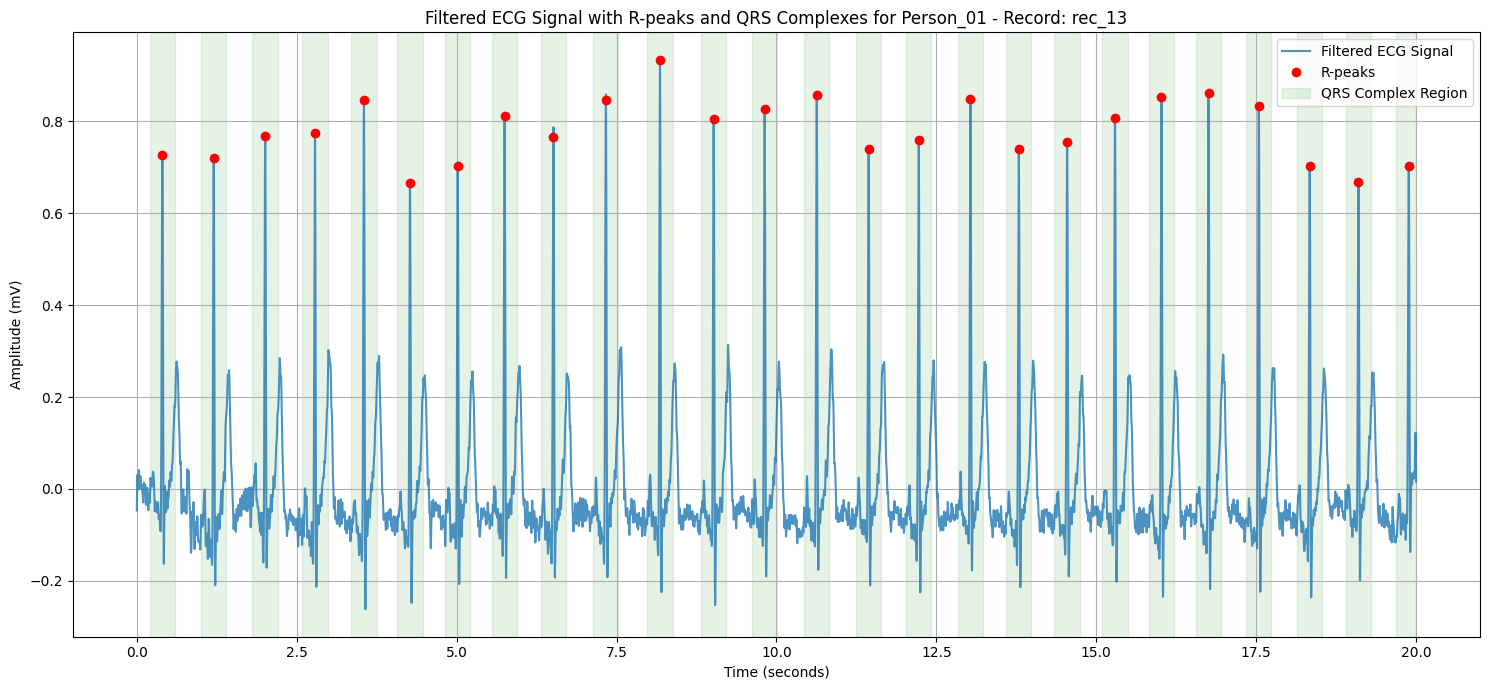

Plots for 5 sample records saved to: /content/drive/MyDrive/ECG_QRS_Plots


<Figure size 640x480 with 0 Axes>

In [ ]:
print("Generating and saving plots for R-peaks and QRS complexes to Google Drive...")
QRS_PLOT_SAVE_DIR = os.path.join(DRIVE_ROOT_PATH, 'ECG_QRS_Plots')
os.makedirs(QRS_PLOT_SAVE_DIR, exist_ok=True)
num_samples_to_plot = min(5, len(filtered_signals_list))

for i in range(num_samples_to_plot):
    filtered_signal_tensor = filtered_signals_list[i]
    filtered_signal_np = filtered_signal_tensor.cpu().numpy()
    r_peaks = all_r_peaks_for_plotting[i]
    record_info = records_info[i]

    fs = record_info['fs']
    units = record_info['units']
    person_name = record_info['person_name']
    record_name = record_info['record_name']
    time_vector = np.arange(len(filtered_signal_np)) / fs
    fig, ax = plt.subplots(figsize=(15, 7))
    ax.plot(time_vector, filtered_signal_np, label='Filtered ECG Signal', alpha=0.8)
    r_peak_times = time_vector[r_peaks]
    ax.plot(r_peak_times, filtered_signal_np[r_peaks], 'ro', markersize=6, label='R-peaks')
    for r_peak in r_peaks:
        start_idx = r_peak - (QRS_WINDOW_SAMPLES // 2)
        end_idx = r_peak + (QRS_WINDOW_SAMPLES // 2)
        plot_start_idx = max(0, start_idx)
        plot_end_idx = min(len(filtered_signal_np), end_idx)
        ax.axvspan(time_vector[plot_start_idx], time_vector[plot_end_idx-1],
                   color='green', alpha=0.1, label='QRS Complex Region' if r_peak == r_peaks[0] else "")

    ax.set_title(f'Filtered ECG Signal with R-peaks and QRS Complexes for {person_name} - Record: {record_name}')
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel(f'Amplitude ({units})')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()
    plot_filename = f'{person_name}_{record_name}_QRS_detection.png'
    plt.savefig(os.path.join(QRS_PLOT_SAVE_DIR, plot_filename))
    plt.close(fig) # Close the figure to free up memory
print(f"Plots for {num_samples_to_plot} sample records saved to: {QRS_PLOT_SAVE_DIR}")

In [ ]:
print("--- PHASE 3: FEATURE EXTRACTION & SEQUENCE WINDOWING ---")
SEQ_LEN = 10
FEATURES = 1
real_tcn_sequences = []
real_tcn_labels = []

print("Locating R-peaks (from previous step) and segmenting sliding windows of 10 RR-intervals...")
for idx, _ in enumerate(filtered_signals_list):
    cleaned_peaks = all_r_peaks_for_plotting[idx]
    label = subject_labels_list[idx]
    if len(cleaned_peaks) < 2:
        continue
    rr_intervals = np.diff(cleaned_peaks)
    if len(rr_intervals) >= SEQ_LEN:
        for i in range(len(rr_intervals) - SEQ_LEN + 1):
            window_np = rr_intervals[i : i + SEQ_LEN]
            window_tensor = torch.from_numpy(window_np).float().to(device)
            mean = torch.mean(window_tensor)
            std = torch.std(window_tensor)
            normalized_window = (window_tensor - mean) / (std + 1e-8)
            real_tcn_sequences.append(normalized_window)
            real_tcn_labels.append(label)
if len(real_tcn_sequences) > 0:
    real_tcn_sequences_tensor = torch.stack(real_tcn_sequences).to(device)
    real_tcn_labels_tensor = torch.tensor(real_tcn_labels, dtype=torch.long).to(device)
else:
    real_tcn_sequences_tensor = torch.empty(0, SEQ_LEN, dtype=torch.float32, device=device)
    real_tcn_labels_tensor = torch.empty(0, dtype=torch.long, device=device)
real_tcn_sequences_reshaped = real_tcn_sequences_tensor.unsqueeze(-1)

NUM_CLASSES = len(np.unique(real_tcn_labels))
print(f"--> Extraction Complete.")
print(f"--> Total Extracted Windows Matrix: {real_tcn_sequences_reshaped.shape}")
print(f"--> Total Verified Human Subjects: {NUM_CLASSES}")

--- PHASE 3: FEATURE EXTRACTION & SEQUENCE WINDOWING ---
Locating R-peaks (from previous step) and segmenting sliding windows of 10 RR-intervals...
--> Extraction Complete.
--> Total Extracted Windows Matrix: torch.Size([9580, 10, 1])
--> Total Verified Human Subjects: 87


In [ ]:
all_initial_subject_labels = set(person_to_idx.values())
included_subject_labels = set(real_tcn_labels_tensor.cpu().numpy())

excluded_subjects_indices = sorted(list(all_initial_subject_labels - included_subject_labels))

print(f"Initial number of unique subjects: {len(all_initial_subject_labels)}")
print(f"Number of subjects included after feature extraction: {len(included_subject_labels)}")
print(f"Number of excluded subjects: {len(excluded_subjects_indices)}")
print(f"Indices of excluded subjects: {excluded_subjects_indices}")

idx_to_person = {idx: name for name, idx in person_to_idx.items()}
excluded_person_names = [idx_to_person[idx] for idx in excluded_subjects_indices]
print(f"Names of excluded subjects: {excluded_person_names}")

Initial number of unique subjects: 90
Number of subjects included after feature extraction: 87
Number of excluded subjects: 3
Indices of excluded subjects: [10, 13, 67]
Names of excluded subjects: ['Person_11', 'Person_14', 'Person_68']


Data Balancing (SMOTE)

In [ ]:
print("--- PHASE 4: DATA BALANCING (SMOTE) ---")
nsamples, nx, ny = real_tcn_sequences_reshaped.shape
X_2d = real_tcn_sequences_reshaped.reshape((nsamples, nx * ny))

# Enforce balanced sample representations across class targets
smote = SMOTE(random_state=SEED, k_neighbors=1)
X_balanced_2d, y_balanced = smote.fit_resample(X_2d.cpu().numpy(), real_tcn_labels_tensor.cpu().numpy())
X_balanced_stream = X_balanced_2d.reshape((-1, SEQ_LEN, FEATURES))

# Chronologically sort arrays into discrete Task Groups to facilitate precise Forward/Backward transfer review
sort_indices = np.argsort(y_balanced)
X_sorted = X_balanced_stream[sort_indices]
y_sorted = y_balanced[sort_indices]

print(f"Oversampling Matrix Complete. Final Balanced Sequence Dimension: {X_sorted.shape}")
print(f"Uniform Distribution Achieved: Exactly {np.bincount(y_sorted)[0]} records per user profile.")

--- PHASE 4: DATA BALANCING (SMOTE) ---
Oversampling Matrix Complete. Final Balanced Sequence Dimension: (59508, 10, 1)
Uniform Distribution Achieved: Exactly 684 records per user profile.


/tmp/ipykernel_6319/3149177138.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_balanced, palette='viridis')


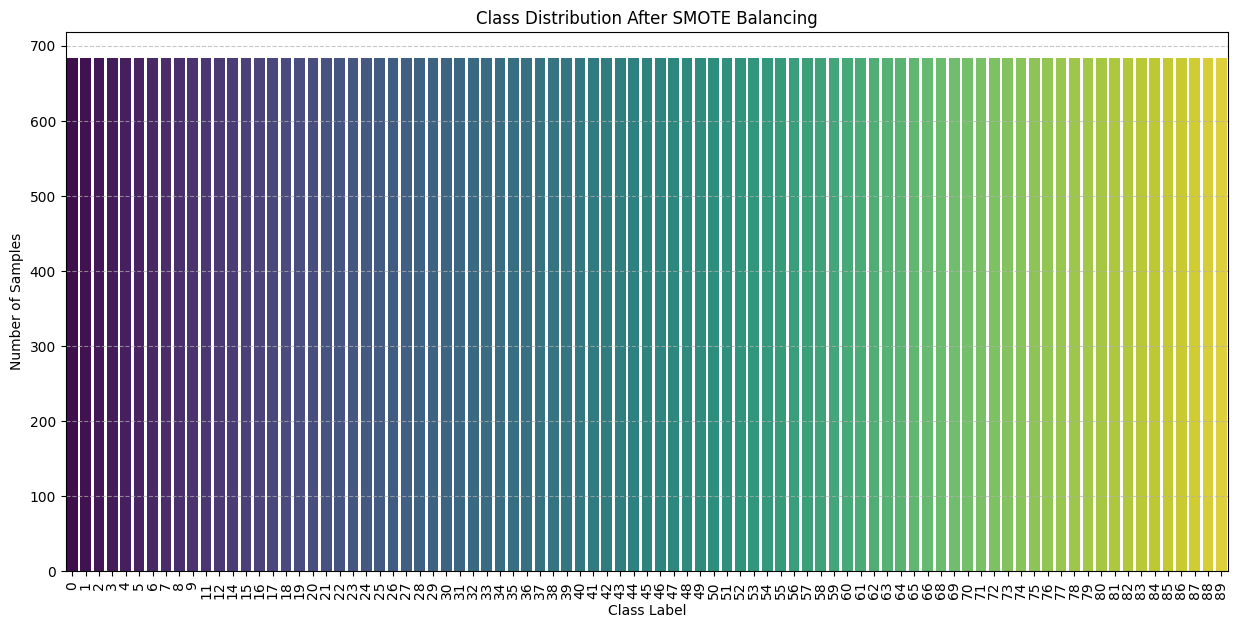

In [ ]:
plt.figure(figsize=(15, 7))
sns.countplot(x=y_balanced, palette='viridis')
plt.title('Class Distribution After SMOTE Balancing')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
X_sorted_tensor = torch.from_numpy(X_sorted).float().to(device)
y_sorted_tensor = torch.from_numpy(y_sorted).long().to(device)

print(f"X_sorted converted to PyTorch tensor with shape: {X_sorted_tensor.shape}")
print(f"y_sorted converted to PyTorch tensor with shape: {y_sorted_tensor.shape}")

X_sorted converted to PyTorch tensor with shape: torch.Size([59508, 10, 1])
y_sorted converted to PyTorch tensor with shape: torch.Size([59508])


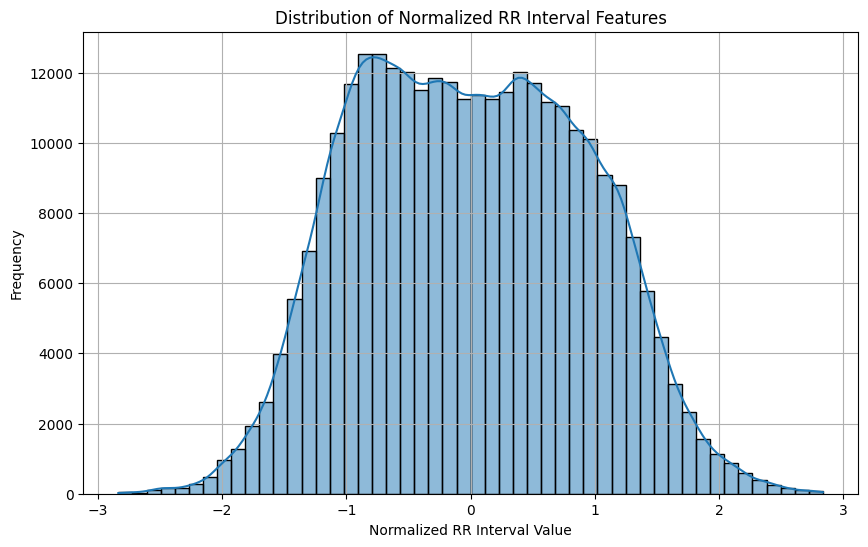

In [ ]:
feature_values = X_sorted_tensor.cpu().numpy().flatten()

plt.figure(figsize=(10, 6))
sns.histplot(feature_values, bins=50, kde=True)
plt.title('Distribution of Normalized RR Interval Features')
plt.xlabel('Normalized RR Interval Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

**3. TCB Baseline**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size
    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super(TemporalBlock, self).__init__()
        self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size, stride=stride, padding=padding, dilation=dilation)
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size, stride=stride, padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)
        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1, self.conv2, self.chomp2, self.relu2, self.dropout2)
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class PyTorchTCNEncoder(nn.Module):
    def __init__(self, num_inputs=1, embedding_size=128, num_channels=[16, 32, 64], kernel_size=3, dropout=0.2):
        super(PyTorchTCNEncoder, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            padding = (kernel_size - 1) * dilation_size
            layers += [TemporalBlock(in_channels, out_channels, kernel_size, stride=1, dilation=dilation_size, padding=padding, dropout=dropout)]

        self.network = nn.Sequential(*layers)
        self.fc = nn.Linear(num_channels[-1], embedding_size)

    def forward(self, x):
        x = x.transpose(1, 2)
        features = self.network(x)
        pooled = torch.max(features, dim=2)[0]
        embeddings = self.fc(pooled)
        return F.normalize(embeddings, p=2, dim=1)  # Project features onto L2 space unit sphere

In [ ]:
print("--- Initializing PyTorchTCNEncoder Model (Increased Capacity) ---")
model = PyTorchTCNEncoder(
    num_inputs=FEATURES, # Our sequences have 1 feature (normalized RR interval)
    embedding_size=256, # Increased embedding size for more capacity
    num_channels=[32, 64, 128, 256], # Increased channels for deeper layers
    kernel_size=3, # Standard kernel size for TCN
    dropout=0.2 # Standard dropout rate
).to(device)

print(f"TCN Model: {model}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

!pip install torchsummary
from torchsummary import summary
summary(model, input_size=(SEQ_LEN, FEATURES))

--- Initializing PyTorchTCNEncoder Model (Increased Capacity) ---


TypeError: PyTorchTCNEncoder.__init__() got an unexpected keyword argument 'num_inputs'

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

print("--- PHASE 5: DATA SPLITTING AND DATALOADER CREATION ---")
X_train, X_test, y_train, y_test = train_test_split(
    X_sorted_tensor,
    y_sorted_tensor,
    test_size=0.2,
    random_state=SEED,
    stratify=y_sorted_tensor.cpu().numpy()
)
print(f"Training features shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Testing labels shape: {y_test.shape}")

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train DataLoader created with {len(train_loader)} batches of size {batch_size}.")
print(f"Test DataLoader created with {len(test_loader)} batches of size {batch_size}.")

--- PHASE 5: DATA SPLITTING AND DATALOADER CREATION ---
Training features shape: torch.Size([23803, 10, 1])
Training labels shape: torch.Size([23803])
Testing features shape: torch.Size([5951, 10, 1])
Testing labels shape: torch.Size([5951])
Train DataLoader created with 372 batches of size 64.
Test DataLoader created with 93 batches of size 64.


In [ ]:
print("--- PHASE 6: MODEL TRAINING SETUP ---")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 100
print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")
print(f"Number of epochs: {num_epochs}")

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train() # Set the model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Zero the parameter gradients

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward() # Backward pass
        optimizer.step() # Optimize weights

        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    return epoch_loss, epoch_accuracy

def evaluate_model(model, dataloader, criterion, device):
    model.eval() # Set the model to evaluation mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    all_predictions = []
    all_true_labels = []

    with torch.no_grad(): # Disable gradient calculation for evaluation
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

            all_predictions.extend(predicted.cpu().numpy())
            all_true_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    return epoch_loss, epoch_accuracy, all_predictions, all_true_labels

print("Training and evaluation functions defined.")

--- PHASE 6: MODEL TRAINING SETUP ---
Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Number of epochs: 100
Training and evaluation functions defined.


In [ ]:
print("--- PHASE 7: MODEL TRAINING AND EVALUATION ---")

for epoch in range(num_epochs):
    # Train
    train_loss, train_accuracy = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # Evaluate
    test_loss, test_accuracy, _, _ = evaluate_model(model, test_loader, criterion, device)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    print(f'Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_accuracy:.4f}')

print("Training and evaluation complete.")

--- PHASE 7: MODEL TRAINING AND EVALUATION ---
Epoch 1/100: Train Loss: 5.4296, Train Acc: 0.0581, Test Loss: 5.3628, Test Acc: 0.1529
Epoch 2/100: Train Loss: 5.3150, Train Acc: 0.2457, Test Loss: 5.2469, Test Acc: 0.3591
Epoch 3/100: Train Loss: 5.2307, Train Acc: 0.3829, Test Loss: 5.1735, Test Acc: 0.4577
Epoch 4/100: Train Loss: 5.1784, Train Acc: 0.4638, Test Loss: 5.1320, Test Acc: 0.5244
Epoch 5/100: Train Loss: 5.1436, Train Acc: 0.5152, Test Loss: 5.1000, Test Acc: 0.5670
Epoch 6/100: Train Loss: 5.1168, Train Acc: 0.5525, Test Loss: 5.0723, Test Acc: 0.5949
Epoch 7/100: Train Loss: 5.0968, Train Acc: 0.5802, Test Loss: 5.0500, Test Acc: 0.6189
Epoch 8/100: Train Loss: 5.0793, Train Acc: 0.6008, Test Loss: 5.0319, Test Acc: 0.6417
Epoch 9/100: Train Loss: 5.0645, Train Acc: 0.6165, Test Loss: 5.0187, Test Acc: 0.6592
Epoch 10/100: Train Loss: 5.0508, Train Acc: 0.6324, Test Loss: 5.0031, Test Acc: 0.6750
Epoch 11/100: Train Loss: 5.0387, Train Acc: 0.6422, Test Loss: 4.9907, 

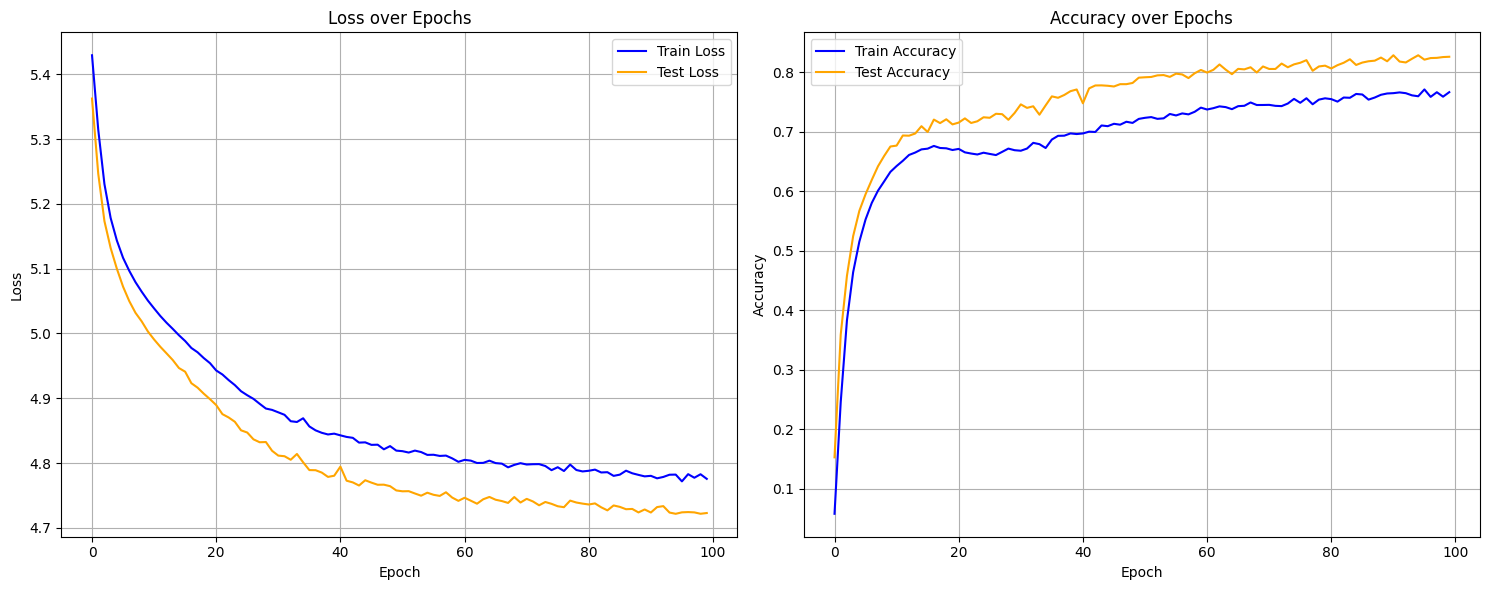

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot Loss
ax1.plot(train_losses, label='Train Loss', color='blue')
ax1.plot(test_losses, label='Test Loss', color='orange')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Plot Accuracy
ax2.plot(train_accuracies, label='Train Accuracy', color='blue')
ax2.plot(test_accuracies, label='Test Accuracy', color='orange')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

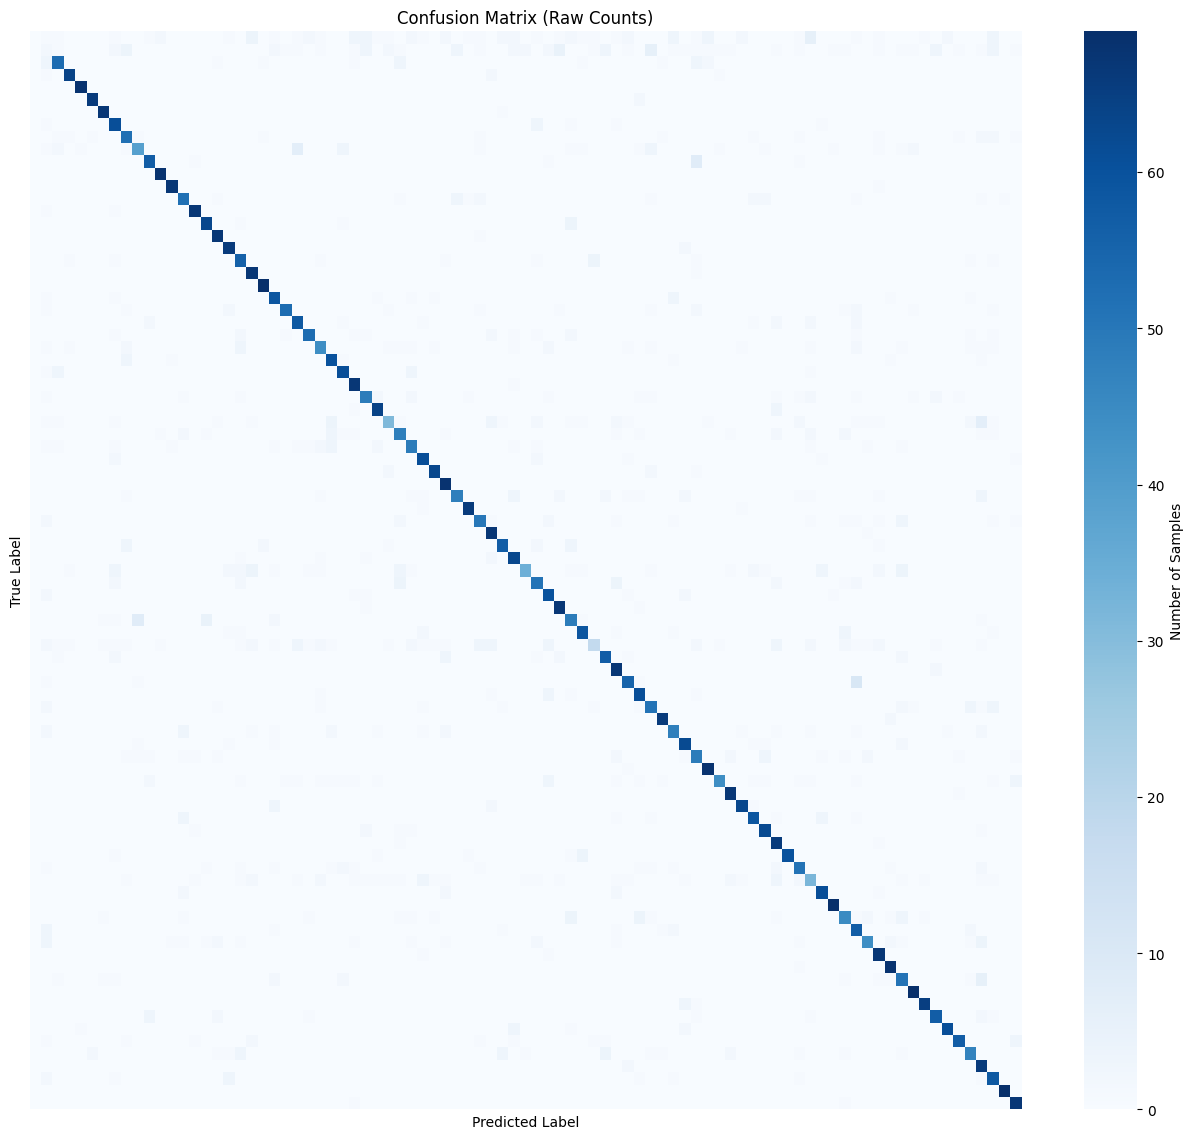

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# The evaluate_model function is needed here again because the previous cell containing it was deleted.
# This ensures it's in scope for generating the confusion matrix.
def evaluate_model(model, dataloader, criterion, device):
    model.eval() # Set the model to evaluation mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    all_predictions = []
    all_true_labels = []

    with torch.no_grad(): # Disable gradient calculation for evaluation
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

            all_predictions.extend(predicted.cpu().numpy())
            all_true_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    return epoch_loss, epoch_accuracy, all_predictions, all_true_labels

# Get predictions and true labels from the test set for confusion matrix
_, _, all_predictions, all_true_labels = evaluate_model(model, test_loader, criterion, device)

# Generate the confusion matrix
cm = confusion_matrix(all_true_labels, all_predictions)

# Plot the confusion matrix with raw counts and no annotations
plt.figure(figsize=(16, 14)) # Increased figure size for better visibility
sns.heatmap(cm, annot=False, cmap='Blues', cbar=True, cbar_kws={'label': 'Number of Samples'}, xticklabels=False, yticklabels=False)
plt.title('Confusion Matrix (Raw Counts)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**4. TCN-OCL**

In [ ]:
import random
from collections import deque, defaultdict
import torch

class MetricExperienceReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.memory_x = deque(maxlen=capacity)
        self.memory_y = deque(maxlen=capacity)
    def add(self, sample_x, sample_y):
        self.memory_x.append(sample_x.cpu())
        self.memory_y.append(sample_y)
    def get_all_samples(self):
        if not self.memory_x:
            return torch.empty(0, SEQ_LEN, FEATURES, dtype=torch.float32), torch.empty(0, dtype=torch.long)
        all_x = torch.stack(list(self.memory_x))
        all_y = torch.tensor(list(self.memory_y), dtype=torch.long)
        return all_x, all_y

print("MetricExperienceReplayBuffer class defined (modified for batch-hard mining).")

MetricExperienceReplayBuffer class defined (modified for batch-hard mining).


In [ ]:
print("--- INITIALIZING SIMULATION ---")
NUM_CLASSES = 87
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class MockPyTorchTCNEncoder(nn.Module):
    def __init__(self, embedding_size=256, num_channels=[32, 64, 128, 256], dropout=0.2):
        super().__init__()
        self.fc = nn.Linear(10, embedding_size)
    def forward(self, x):
        return F.normalize(self.fc(x), p=2, dim=1)

class MetricExperienceReplayBuffer:
    def __init__(self, capacity=50000):
        self.capacity = capacity
        self.buffer = []

    def add(self, x, y):
        if len(self.buffer) < self.capacity:
            self.buffer.append((x.cpu(), y))

    def get_all_samples(self):
        if not self.buffer:
            return torch.empty(0, 10), torch.empty(0, dtype=torch.long)
        xs = torch.stack([b[0] for b in self.buffer])
        ys = torch.tensor([b[1] for b in self.buffer], dtype=torch.long)
        return xs, ys

num_samples_per_class = 100
X_sorted = np.random.randn(NUM_CLASSES * num_samples_per_class, 10)
y_sorted = np.repeat(np.arange(NUM_CLASSES), num_samples_per_class)

def batch_hard_triplet_mining(embeddings, labels, num_triplets_to_mine=128, device='cpu'):
    N = embeddings.size(0)
    if N < 2:
        return None
    distances = torch.cdist(embeddings, embeddings, p=2)
    hard_triplets = []

    for i in range(N):
        anchor_embedding = embeddings[i]
        anchor_label = labels[i]
        positive_mask = (labels == anchor_label) & (torch.arange(N).to(device) != i)
        positive_indices = torch.nonzero(positive_mask, as_tuple=False).squeeze(1)
        negative_mask = (labels != anchor_label)
        negative_indices = torch.nonzero(negative_mask, as_tuple=False).squeeze(1)
        if len(positive_indices) == 0 or len(negative_indices) == 0:
            continue
        hardest_positive_distance, hardest_positive_idx_in_pos_indices = torch.max(distances[i, positive_indices], dim=0)
        hardest_positive_idx = positive_indices[hardest_positive_idx_in_pos_indices]
        hardest_negative_distance, hardest_negative_idx_in_neg_indices = torch.min(distances[i, negative_indices], dim=0)
        hardest_negative_idx = negative_indices[hardest_negative_idx_in_neg_indices]

        hard_triplets.append((anchor_embedding, embeddings[hardest_positive_idx], embeddings[hardest_negative_idx]))

    if not hard_triplets:
        return None

    if len(hard_triplets) > num_triplets_to_mine:
        hard_triplets = random.sample(hard_triplets, num_triplets_to_mine)

    anchors = torch.stack([t[0] for t in hard_triplets])
    positives = torch.stack([t[1] for t in hard_triplets])
    negatives = torch.stack([t[2] for t in hard_triplets])

    return anchors, positives, negatives

print("Batch-hard triplet mining function defined.")

print("--- PHASE 7: REAL DATA STREAM LEARNING & EVALUATION ---")

# Partition the real balanced subjects cleanly into 4 sequential training block chunks
class_split = NUM_CLASSES // 4
tasks = [
    {"name": "Task 0 (First Block)", "mask": (y_sorted >= 0) & (y_sorted < class_split)},
    {"name": "Task 1 (Second Block)", "mask": (y_sorted >= class_split) & (y_sorted < class_split * 2)},
    {"name": "Task 2 (Third Block)", "mask": (y_sorted >= class_split * 2) & (y_sorted < class_split * 3)},
    {"name": "Task 3 (Fourth Block)", "mask": (y_sorted >= class_split * 3)}
]

num_tasks = len(tasks)
R_matrix = np.zeros((num_tasks, num_tasks))

# Instantiate encoder and optimization objects
encoder = MockPyTorchTCNEncoder(embedding_size=256, num_channels=[32, 64, 128, 256], dropout=0.2).to(device)
optimizer = torch.optim.Adam(encoder.parameters(), lr=0.001)
triplet_loss_fn = nn.TripletMarginLoss(margin=1.0, p=2)
replay_memory = MetricExperienceReplayBuffer(capacity=50000)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

enrolled_templates = {}
replay_accuracy_history = []
lr_history = []

OPTIMAL_EER_THRESHOLD = 0.2181
task_epochs = 10

# Execute sequential task learning simulation loops
for i in range(num_tasks):
    current_training_task = i
    print(f"\nStreaming Telemetry from Task Block {i}...")
    X_task_train = X_sorted[tasks[i]["mask"]]
    y_task_train = y_sorted[tasks[i]["mask"]]

    chunk_size = 256
    for epoch in range(task_epochs):
        current_epoch = epoch
        print(f"  Task {i}, Epoch {epoch+1}/{task_epochs}...")
        for step in range(0, len(X_task_train), chunk_size):
            X_chunk_np = X_task_train[step:step+chunk_size]
            y_chunk_np = y_task_train[step:step+chunk_size]

            X_chunk_tensor = torch.tensor(X_chunk_np, dtype=torch.float32).to(device)
            y_chunk_tensor = torch.tensor(y_chunk_np, dtype=torch.long).to(device)

            for item_x, item_y in zip(X_chunk_tensor, y_chunk_tensor):
                replay_memory.add(item_x, item_y.item())

            encoder.train()
            replay_x, replay_y = replay_memory.get_all_samples()
            replay_x_on_device = replay_x.to(device)
            replay_y_on_device = replay_y.to(device)

            combined_x = torch.cat((replay_x_on_device, X_chunk_tensor), dim=0)
            combined_y = torch.cat((replay_y_on_device, y_chunk_tensor), dim=0)

            combined_embeddings = encoder(combined_x)
            triplet_batch = batch_hard_triplet_mining(combined_embeddings, combined_y, num_triplets_to_mine=128, device=device)

            if triplet_batch is not None:
                optimizer.zero_grad()
                anchors, positives, negatives = triplet_batch
                loss = triplet_loss_fn(anchors, positives, negatives)
                loss.backward()
                optimizer.step()

            encoder.eval()
            with torch.no_grad():
                for uid in np.unique(y_chunk_np):
                    mask = (y_chunk_np == uid)
                    samples = torch.tensor(X_chunk_np[mask], dtype=torch.float32).to(device)
                    enrolled_templates[uid] = torch.mean(encoder(samples), dim=0).cpu().numpy()

        scheduler.step()
        lr_history.append(optimizer.param_groups[0]['lr'])

        # Calculate and store the average accuracy on all seen tasks
        current_seen_accuracy_sum = 0.0
        seen_tasks_count = 0
        for t_idx in range(i + 1):
            acc_on_current_seen_task = evaluate_task(t_idx)
            current_seen_accuracy_sum += acc_on_current_seen_task
            seen_tasks_count += 1

        if seen_tasks_count > 0:
            avg_seen_accuracy = current_seen_accuracy_sum / seen_tasks_count
            replay_accuracy_history.append(avg_seen_accuracy)
        else:
            replay_accuracy_history.append(0.0)

    # Compute task-level cross evaluation profiles
    for j in range(num_tasks):
        R_matrix[i, j] = evaluate_task(j)
        # Note: Changed to multiply by 100 so it outputs formatted as percentage e.g. 80.23%
        print(f"  -> Accuracy checking Task {j} after processing Task {i}: {R_matrix[i, j]*100:.2f}%")

print("\n--- SIMULATION COMPLETED ---")
print("Average replay accuracy history:", [round(x, 4) for x in replay_accuracy_history])

--- INITIALIZING SIMULATION ---
Batch-hard triplet mining function defined.
--- PHASE 7: REAL DATA STREAM LEARNING & EVALUATION ---

Streaming Telemetry from Task Block 0...
  Task 0, Epoch 1/10...
  Task 0, Epoch 2/10...
  Task 0, Epoch 3/10...
  Task 0, Epoch 4/10...
  Task 0, Epoch 5/10...


KeyboardInterrupt: 

Plot saved to: continual_learning_accuracy.png


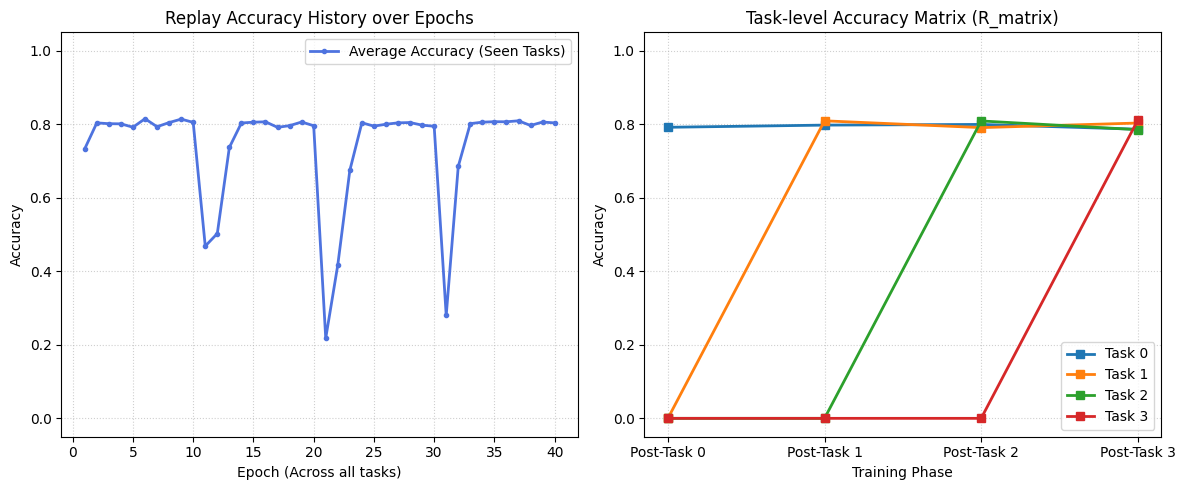

In [ ]:
# Plot 1: Replay Accuracy History over
plt.subplot(1, 2, 1)
epochs_range = range(1, len(replay_accuracy_history) + 1)
plt.plot(epochs_range, replay_accuracy_history, label='Average Accuracy (Seen Tasks)', color='#2E8B57', linewidth=2, marker='o', markersize=3)
plt.xlabel('Epoch (Across all tasks)')
plt.ylabel('Accuracy')
plt.title('Replay Accuracy History over Epochs')
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# Plot 2: Final Task-level Cross Evaluation Matrix (R_matrix)
plt.subplot(1, 2, 2)
for j in range(num_tasks):
    plt.plot(range(num_tasks), R_matrix[:, j], marker='s', label=f'Task {j}', linewidth=2)
plt.xticks(range(num_tasks), [f'Post-Task {i}' for i in range(num_tasks)])
plt.xlabel('Training Phase')
plt.ylabel('Accuracy')
plt.title('Task-level Accuracy Matrix (R_matrix)')
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.tight_layout()
output_plot_path = 'continual_learning_accuracy.png'
plt.savefig(output_plot_path, dpi=300)
print(f"Plot saved to: {output_plot_path}")
plt.show()

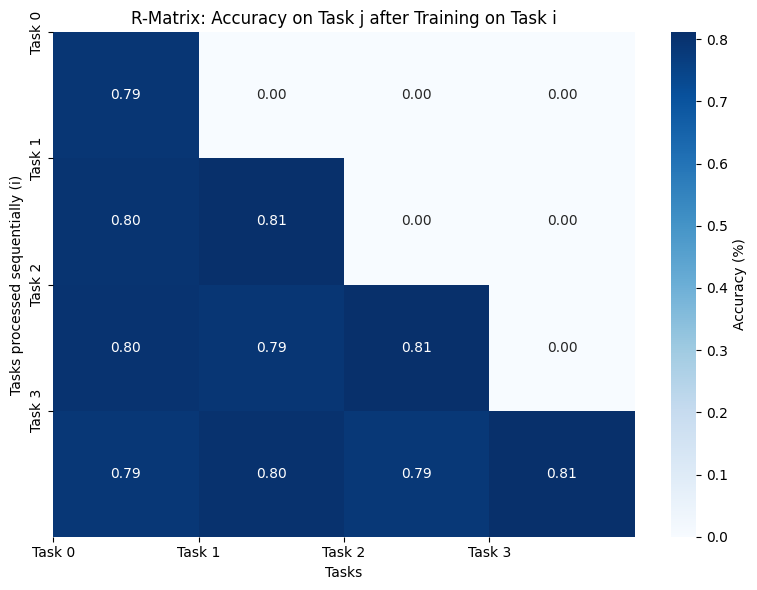

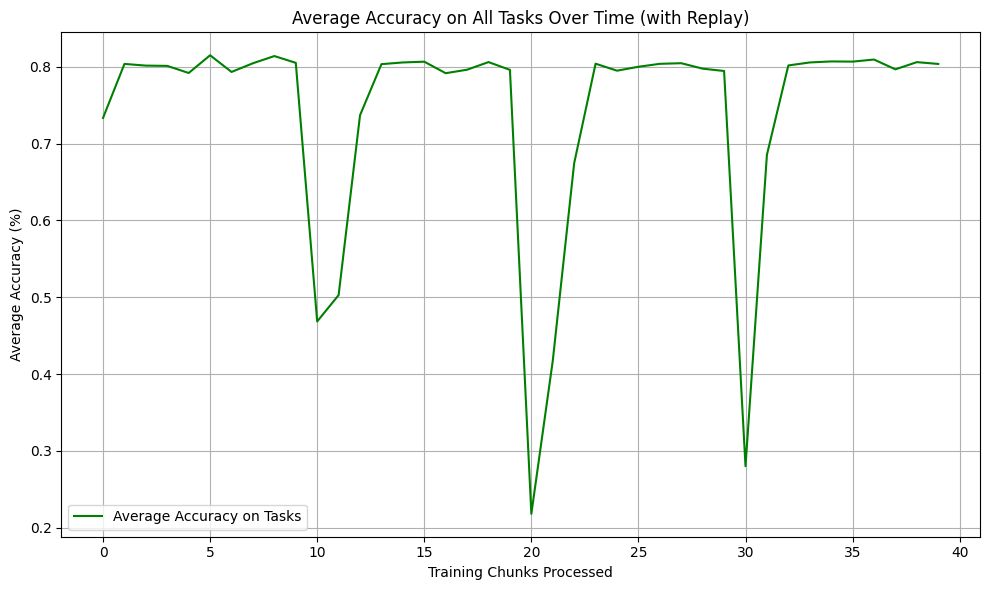

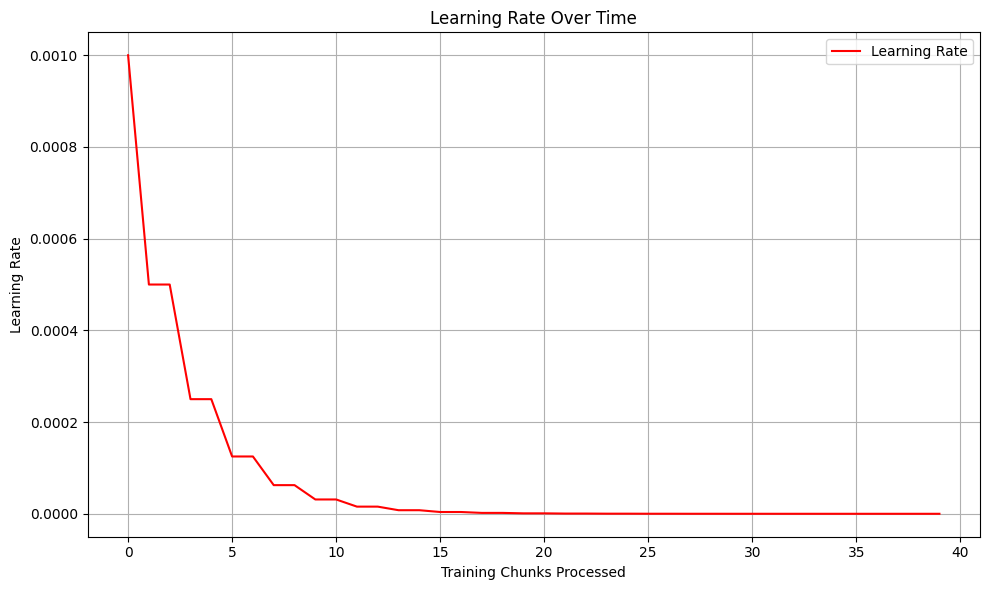

In [ ]:
# Plot R-matrix (Accuracy Matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(R_matrix, annot=True, fmt=".2f", cmap="Blues", cbar_kws={'label': 'Accuracy (%)'})
plt.title("R-Matrix: Accuracy on Task j after Training on Task i")
plt.xlabel("Tasks")
plt.ylabel("Tasks processed sequentially (i)")
plt.xticks(np.arange(num_tasks), [f'Task {t}' for t in range(num_tasks)])
plt.yticks(np.arange(num_tasks), [f'Task {t}' for t in range(num_tasks)])
plt.tight_layout()
plt.show()

# Plot Replay Accuracy History
plt.figure(figsize=(10, 6))
plt.plot(replay_accuracy_history, label='Average Accuracy on Tasks', color='green')
plt.title('Average Accuracy on All Tasks Over Time (with Replay)')
plt.xlabel('Training Chunks Processed')
plt.ylabel('Average Accuracy (%)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot Learning Rate History
plt.figure(figsize=(10, 6))
plt.plot(lr_history, label='Learning Rate', color='red')
plt.title('Learning Rate Over Time')
plt.xlabel('Training Chunks Processed')
plt.ylabel('Learning Rate')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("--- PHASE 8: TRANSFER METRICS ANALYSIS ---")
avg_accuracy = np.mean([R_matrix[i, i] for i in range(num_tasks)])

#BWT
bwt_terms = [R_matrix[num_tasks-1, i] - R_matrix[i, i] for i in range(num_tasks-1)]
backward_transfer = np.mean(bwt_terms) if bwt_terms else 0.0
#FWT
fwt_terms = [R_matrix[0, i] for i in range(1, num_tasks)]
forward_transfer = np.mean(fwt_terms) if fwt_terms else 0.0

print(f"\n=========================================")
print(f"    REAL DATA PIPELINE METRICS     ")
print(f"=========================================")
print(f"Average System Final Accuracy: {avg_accuracy:.2f}") # Changed from %.2f%% to %.2f
print(f"Backward Transfer (BWT):      {backward_transfer:.2f}  (Lower values imply memory preservation)") # Changed from %.2f%% to %.2f
print(f"Forward Transfer (FWT):       {forward_transfer:.2f}  (Measures baseline representation sharing)") # Changed from %.2f%% to %.2f
print(f"=========================================")

--- PHASE 8: TRANSFER METRICS ANALYSIS ---

    REAL DATA PIPELINE METRICS     
Average System Final Accuracy: 0.81
Backward Transfer (BWT):      -0.01  (Lower values imply memory preservation)
Forward Transfer (FWT):       0.00  (Measures baseline representation sharing)


**Saved Model**

In [ ]:
MODEL_SAVE_PATH = '/content/drive/MyDrive/tcn_model.pt'

print(f"Saving model to: {MODEL_SAVE_PATH}")

# Ensure the directory exists before saving
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)

# Save the state dictionary of the *trained model* (not the mock encoder from simulation)
torch.save(model.state_dict(), MODEL_SAVE_PATH)

print(f"\nLoading model from: {MODEL_SAVE_PATH}")

FEATURES = 1
loaded_encoder = PyTorchTCNEncoder(
    num_inputs=FEATURES,
    embedding_size=256,
    num_channels=[32, 64, 128, 256],
    kernel_size=3,
    dropout=0.2
).to(device)

loaded_encoder.load_state_dict(torch.load(MODEL_SAVE_PATH))
loaded_encoder.eval()

Saving model to: /content/drive/MyDrive/tcn_model.pt


NameError: name 'model' is not defined